# A01 — Complex Amplitudes and the Qubit State

**Track A — under the hood.** Pure NumPy. Qiskit is not imported anywhere in this
notebook; every number here is one you can derive with a pen.

---

## The one-sentence version

A classical bit is a number that is either 0 or 1. A qubit is a **pair of complex
numbers** — one attached to the label `0`, one attached to the label `1` — and the
only rule is that their squared magnitudes add to 1.

That's it. Everything strange about quantum computing follows from the fact that
those two numbers are *complex* rather than merely positive.

## Why complex numbers, and why you should care

If the two numbers were ordinary probabilities, a qubit would just be a coin that
we haven't looked at yet, and quantum computers would be pointless. Probabilities
are non-negative, so they can only ever pile up. Complex amplitudes can **cancel**.

That cancellation — interference — is the entire source of quantum advantage. A
quantum algorithm is a machine for arranging amplitudes so that the wrong answers
destroy each other and the right answer survives. We'll build that machine over
the next eleven notebooks. This one is about the raw material.

So a qubit state is

$$|\psi\rangle = \alpha\,|0\rangle + \beta\,|1\rangle, \qquad \alpha,\beta \in \mathbb{C},
\qquad |\alpha|^2 + |\beta|^2 = 1.$$

$\alpha$ and $\beta$ are the **amplitudes**. The constraint is the
**normalization condition**. Let's make both concrete.

In [1]:
from qviz import backends, grid, style

import matplotlib.pyplot as plt
import numpy as np

style.use()

SEED = backends.seed_for("A01")
rng = np.random.default_rng(SEED)
print("seed:", SEED)

seed: 20260805


## Building a state, and checking it is legal

We store a qubit as a length-2 complex NumPy array: index 0 holds $\alpha$, index
1 holds $\beta$. Nothing more sophisticated is needed, and nothing is hidden.

In [2]:
def qubit(alpha, beta):
    """A single-qubit state as a length-2 complex vector, normalized."""
    v = np.array([alpha, beta], dtype=complex)
    norm = np.sqrt(np.sum(np.abs(v) ** 2))
    if norm < 1e-12:
        raise ValueError("the zero vector is not a state")
    return v / norm


KET0 = qubit(1, 0)                      # |0>
KET1 = qubit(0, 1)                      # |1>
PLUS = qubit(1, 1)                      # |+> = (|0> + |1>)/sqrt(2)
MINUS = qubit(1, -1)                    # |-> = (|0> - |1>)/sqrt(2)
KET_I = qubit(1, 1j)                    # |+i>
KET_MI = qubit(1, -1j)                  # |-i>

for name, s in [("|0>", KET0), ("|+>", PLUS), ("|+i>", KET_I)]:
    print(f"{name:>5}  alpha={s[0]:+.4f}   beta={s[1]:+.4f}   "
          f"|alpha|^2+|beta|^2 = {np.sum(np.abs(s)**2):.10f}")

  |0>  alpha=+1.0000+0.0000j   beta=+0.0000+0.0000j   |alpha|^2+|beta|^2 = 1.0000000000
  |+>  alpha=+0.7071+0.0000j   beta=+0.7071+0.0000j   |alpha|^2+|beta|^2 = 1.0000000000
 |+i>  alpha=+0.7071+0.0000j   beta=+0.0000+0.7071j   |alpha|^2+|beta|^2 = 1.0000000000


Note $|+\rangle$ and $|-\rangle$: identical magnitudes, differing only in the
**sign** of $\beta$. Measured in the obvious way they are indistinguishable — both
give 0 and 1 half the time. That sign is nevertheless the difference between two
completely different states, and A08 will turn it into a measurable answer.

## The Born rule

The probability of seeing outcome $k$ is the squared magnitude of its amplitude:

$$P(k) = |\langle k|\psi\rangle|^2 = |\psi_k|^2.$$

Squaring is what discards the phase information — and why phase is invisible to a
single measurement while still steering everything that happens before it.

In [3]:
def probabilities(state):
    """Born rule: P(k) = |amplitude_k|^2."""
    return np.abs(state) ** 2


for name, s in [("|0>", KET0), ("|+>", PLUS), ("|->", MINUS), ("|+i>", KET_I)]:
    p = probabilities(s)
    print(f"{name:>5}   P(0)={p[0]:.4f}   P(1)={p[1]:.4f}")

print("\n|+> and |-> have identical probabilities but are different states.")
print("np.allclose(PLUS, MINUS) ->", np.allclose(PLUS, MINUS))

  |0>   P(0)=1.0000   P(1)=0.0000
  |+>   P(0)=0.5000   P(1)=0.5000
  |->   P(0)=0.5000   P(1)=0.5000
 |+i>   P(0)=0.5000   P(1)=0.5000

|+> and |-> have identical probabilities but are different states.
np.allclose(PLUS, MINUS) -> False


## Figure 1 — amplitudes live in the complex plane

An amplitude is an arrow in $\mathbb{C}$: it has a **length** (which drives
probability) and an **angle** (the phase, which drives interference). Plotting
$\alpha$ and $\beta$ as arrows on the Argand plane makes both visible at once.

The dashed circle is the normalization constraint. It is not a circle the
individual arrows must land on — it is the statement that the *hypotenuse* of the
two lengths is 1, so the two arrows trade length against each other.

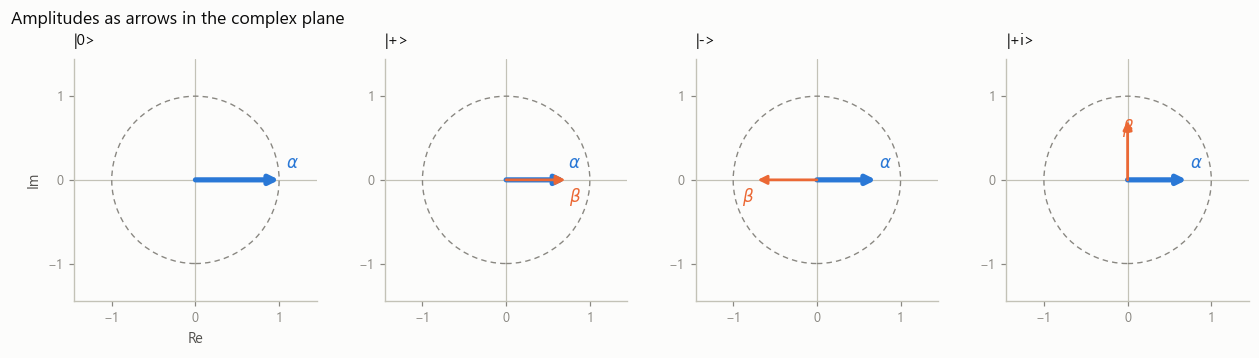

In [4]:
states = [("|0>", KET0), ("|+>", PLUS), ("|->", MINUS), ("|+i>", KET_I)]

fig, axes = plt.subplots(1, 4, figsize=(11.5, 3.1))
for ax, (name, s) in zip(axes, states):
    ax.axhline(0, color=style.AXIS, lw=0.8, zorder=1)
    ax.axvline(0, color=style.AXIS, lw=0.8, zorder=1)
    circ = plt.Circle((0, 0), 1.0, fill=False, ls=(0, (4, 3)),
                      color=style.MUTED, lw=0.9, zorder=1)
    ax.add_patch(circ)
    # alpha is drawn heavier and underneath so that when the two arrows coincide
    # (as they do for |+>) both remain visible; labels are pushed to opposite
    # sides for the same reason.
    for amp, col, lab, lw, z, dy in [
            (s[0], style.BLUE, r"$\alpha$", 3.4, 2, +0.20),
            (s[1], style.ORANGE, r"$\beta$", 1.8, 3, -0.20)]:
        ax.annotate("", xy=(amp.real, amp.imag), xytext=(0, 0), zorder=z,
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=lw,
                                    shrinkA=0, shrinkB=0, mutation_scale=12))
        if abs(amp) > 1e-9:
            ax.text(amp.real * 1.16, amp.imag * 1.16 + dy, lab, color=col,
                    fontsize=11, ha="center", va="center", zorder=4)
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_aspect("equal")
    ax.set_title(name, loc="left", fontsize=10)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.grid(False)

axes[0].set_xlabel("Re")
axes[0].set_ylabel("Im")
fig.suptitle("Amplitudes as arrows in the complex plane", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

Read across: $|0\rangle$ puts everything in $\alpha$. $|+\rangle$ and
$|-\rangle$ split evenly and differ only by $\beta$ pointing left instead of
right — a phase of $\pi$. $|{+}i\rangle$ has $\beta$ pointing *up*: a phase of
$\pi/2$. Same probabilities, three different states.

## Figure 2 — the plot we will use for the rest of the repo

Arrows stop scaling immediately: three qubits already means eight amplitudes, and
sixteen arrows on one plot is unreadable.

So here is the encoding this repo uses everywhere. For each basis state, draw a
bar whose **height is $|$amplitude$|$** and whose **fill colour is the phase**, on
a colour wheel where the two ends meet (because phase wraps at $2\pi$). A little
**clock hand** on top repeats the phase as an angle, so the plot still works if
you can't distinguish the hues — no cyclic colour scheme can be colourblind-safe,
so the hand is not decoration, it's the accessible channel.

One picture, the entire complex vector.

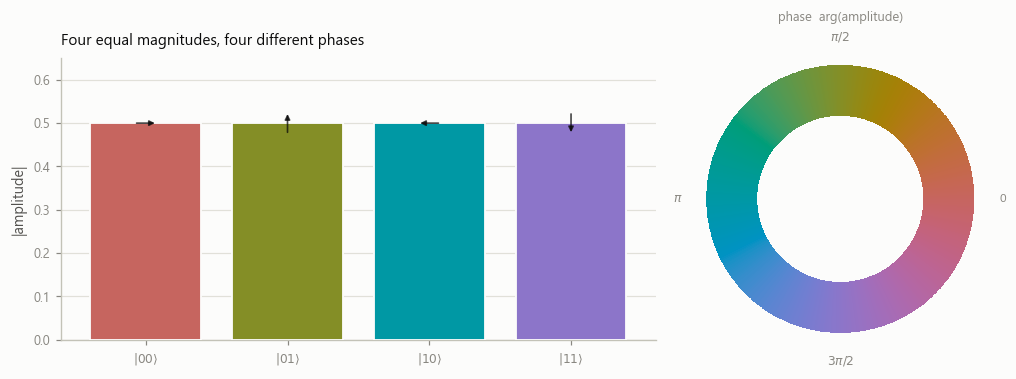

magnitudes: [0.5 0.5 0.5 0.5]
phases/pi : [ 0.   0.5  1.  -0.5]

Identical bar heights => identical measurement statistics.
Different colours/hands => genuinely different states.


In [5]:
demo = np.array([0.5, 0.5j, -0.5, -0.5j])   # magnitudes equal, phases 0, pi/2, pi, 3pi/2

fig = plt.figure(figsize=(9.2, 3.3))
ax = fig.add_subplot(1, 3, (1, 2))
grid.amp_bars(ax, demo, labels=["00", "01", "10", "11"])
ax.set_title("Four equal magnitudes, four different phases", loc="left",
             fontsize=10)

axw = fig.add_subplot(1, 3, 3, projection="polar")
style.phase_wheel(axw)
plt.show()

print("magnitudes:", np.round(np.abs(demo), 3))
print("phases/pi :", np.round(np.angle(demo) / np.pi, 3))
print("\nIdentical bar heights => identical measurement statistics.")
print("Different colours/hands => genuinely different states.")

## Figure 3 — global phase is not physical

Here is the first real subtlety, and it trips up almost everyone.

Multiplying the **whole state** by $e^{i\varphi}$ changes nothing observable:

$$P(k) = |e^{i\varphi}\psi_k|^2 = |e^{i\varphi}|^2|\psi_k|^2 = |\psi_k|^2.$$

That is a **global phase**, and it is not a physical degree of freedom —
$|\psi\rangle$ and $e^{i\varphi}|\psi\rangle$ are the *same state*.

But changing the phase of **one amplitude relative to another** — a **relative
phase** — changes the state completely. The figure below makes the distinction
visible: the top row rotates the whole state (hues all shift together, physics
unchanged); the bottom row rotates only $\beta$ (the state genuinely changes).

Watch the *difference* between the two hues in each panel, not the hues
themselves. Constant difference means nothing happened.

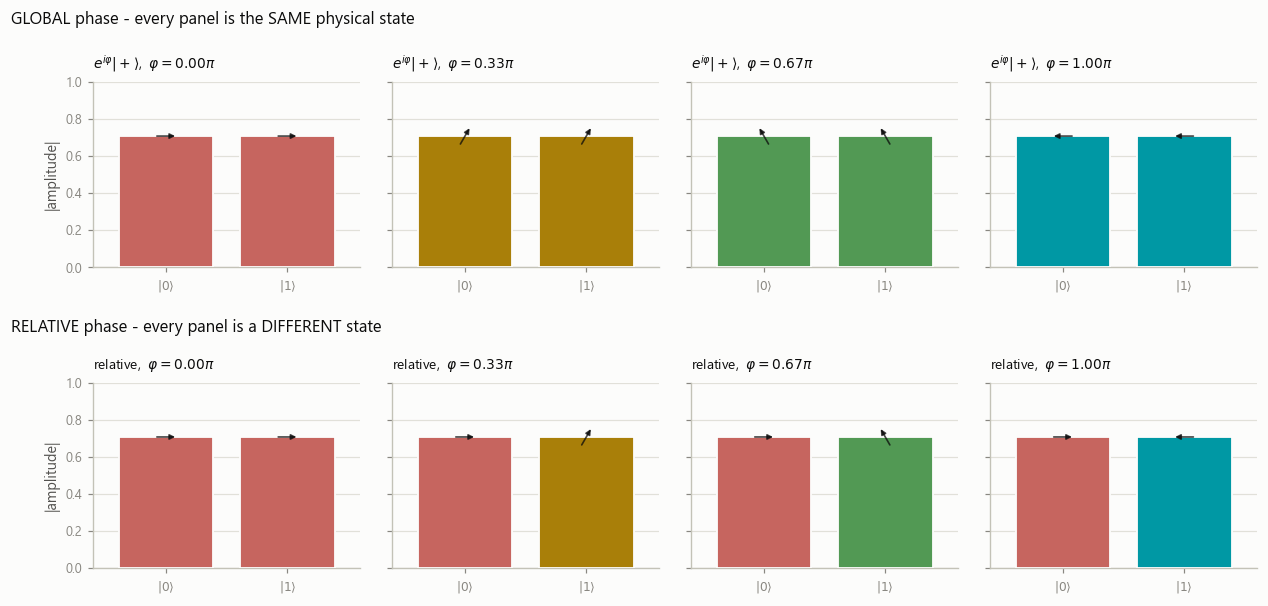

Probabilities along the top row (global phase):
  phi=0.00pi -> [0.5 0.5]
  phi=0.33pi -> [0.5 0.5]
  phi=0.67pi -> [0.5 0.5]
  phi=1.00pi -> [0.5 0.5]

Probabilities along the bottom row (relative phase):
  phi=0.00pi -> [0.5 0.5]
  phi=0.33pi -> [0.5 0.5]
  phi=0.67pi -> [0.5 0.5]
  phi=1.00pi -> [0.5 0.5]


In [6]:
phis = [0, np.pi / 3, 2 * np.pi / 3, np.pi]

# constrained_layout does not reserve space for figure-level text, so this one
# figure is laid out manually to keep the row headers clear of the tick labels.
# layout="none" (the string), not None: None falls through to the rcParam, which
# this repo sets to constrained_layout - and that would override subplots_adjust.
fig, axes = plt.subplots(2, 4, figsize=(11.5, 5.6), sharey=True, layout="none")
fig.subplots_adjust(top=0.86, bottom=0.07, hspace=0.62, wspace=0.12,
                    left=0.07, right=0.99)
for j, phi in enumerate(phis):
    g = np.exp(1j * phi) * PLUS                       # global phase
    r = qubit(PLUS[0], np.exp(1j * phi) * PLUS[1])    # relative phase

    grid.amp_bars(axes[0, j], g, labels=["0", "1"], ylim=1.0)
    grid.amp_bars(axes[1, j], r, labels=["0", "1"], ylim=1.0)

    axes[0, j].set_title(rf"$e^{{i\varphi}}|+\rangle$,  $\varphi={phi/np.pi:.2f}\pi$",
                         loc="left", fontsize=9)
    axes[1, j].set_title(rf"relative,  $\varphi={phi/np.pi:.2f}\pi$",
                         loc="left", fontsize=9)
    for i in (0, 1):
        if j:
            axes[i, j].set_ylabel("")

fig.text(0.005, 0.975, "GLOBAL phase - every panel is the SAME physical state",
         fontsize=11, color=style.INK, weight="medium", va="top")
fig.text(0.005, 0.475, "RELATIVE phase - every panel is a DIFFERENT state",
         fontsize=11, color=style.INK, weight="medium", va="top")
plt.show()

print("Probabilities along the top row (global phase):")
for phi in phis:
    print(f"  phi={phi/np.pi:.2f}pi ->", np.round(probabilities(np.exp(1j*phi) * PLUS), 6))
print("\nProbabilities along the bottom row (relative phase):")
for phi in phis:
    st = qubit(PLUS[0], np.exp(1j * phi) * PLUS[1])
    print(f"  phi={phi/np.pi:.2f}pi ->", np.round(probabilities(st), 6))

Both rows keep probabilities pinned at $(0.5, 0.5)$ — so *this* measurement
cannot tell any of these eight states apart. The top row really is one state
wearing four costumes. The bottom row is four different states that happen to
agree on one question.

The way you distinguish them is to interfere them with something else first,
which is exactly what a Hadamard gate does, and exactly what A08 is about.

## Figure 4 — twelve random states

To get a feel for the space, here are twelve states drawn at random. Each panel
is one qubit: two bars, two hues, two hands.

They are drawn from the **Haar measure** — the uniform distribution on the set of
states — rather than by picking $\alpha$ and $\beta$ from a naive uniform range.
The distinction turns out to matter a great deal, and A02 shows what naive
sampling actually does to the sphere.

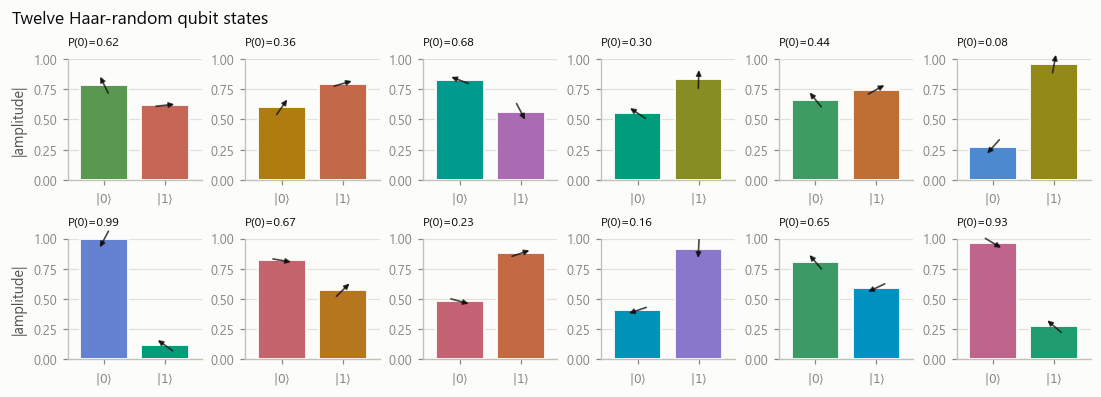

In [7]:
def haar_qubit(rng):
    """Uniformly random pure state: a normalized complex Gaussian vector."""
    v = rng.normal(size=2) + 1j * rng.normal(size=2)
    return v / np.linalg.norm(v)


fig, axes = grid.frames(12, ncols=6, panel=(1.65, 1.75))
for k, ax in enumerate(axes):
    s = haar_qubit(rng)
    grid.amp_bars(ax, s, labels=["0", "1"], ylim=1.0)
    ax.set_title(f"P(0)={np.abs(s[0])**2:.2f}", loc="left", fontsize=8)
    if k % 6:
        ax.set_ylabel("")
fig.suptitle("Twelve Haar-random qubit states", x=0.005, ha="left", fontsize=11.5)
plt.show()

## Deep dive — counting the real degrees of freedom

*Skip this section on a first read; nothing later depends on it.*

Two complex numbers is four real parameters. But:

- **normalization** removes one ($|\alpha|^2 + |\beta|^2 = 1$),
- **global phase** removes another (it is unobservable, as Figure 3 showed).

So a qubit has $4 - 2 = 2$ real degrees of freedom, and we can always write it in
the canonical form

$$|\psi\rangle = \cos\tfrac{\theta}{2}\,|0\rangle + e^{i\phi}\sin\tfrac{\theta}{2}\,|1\rangle,
\qquad \theta \in [0,\pi],\ \phi \in [0,2\pi).$$

Two angles. Two angles is a **sphere** — which is where the Bloch sphere comes
from, and why it is a legitimate picture rather than a convenient cartoon. A02
builds it.

Let's verify the canonical form reproduces an arbitrary state, up to the global
phase we just argued is meaningless.

In [8]:
def to_angles(state):
    """Extract (theta, phi) after dividing out the global phase."""
    a, b = state
    if abs(a) < 1e-12:
        return np.pi, float(np.angle(b))
    b = b * np.exp(-1j * np.angle(a))      # rotate so alpha is real, positive
    a = abs(a)
    theta = 2 * np.arccos(np.clip(a, -1, 1))
    return float(theta), float(np.angle(b) % (2 * np.pi))


def from_angles(theta, phi):
    return np.array([np.cos(theta / 2),
                     np.exp(1j * phi) * np.sin(theta / 2)], dtype=complex)


print(f"{'theta/pi':>9} {'phi/pi':>8}   reconstruction matches (up to global phase)?")
for _ in range(5):
    s = haar_qubit(rng)
    th, ph = to_angles(s)
    back = from_angles(th, ph)
    same = np.allclose(np.abs(np.vdot(back, s)), 1.0)   # |<back|s>| == 1
    print(f"{th/np.pi:9.4f} {ph/np.pi:8.4f}   {same}")

 theta/pi   phi/pi   reconstruction matches (up to global phase)?
   0.2772   1.6782   True
   0.7595   1.2495   True
   0.6065   1.3899   True
   0.2114   0.4929   True
   0.1246   1.7223   True


The test is $|\langle\text{back}|\psi\rangle| = 1$ rather than
`np.allclose(back, s)`. That is the right test precisely *because* global phase is
unphysical: the two vectors may differ by $e^{i\varphi}$ and still be the same
state. Using array equality here is a real and common bug.

## What this picture hides

Being honest about the limits of a visualization is part of using it:

- **Amplitude bars show no entanglement.** For one qubit that's fine. Once we
  have several qubits, a bar chart over $2^n$ basis states is still a complete
  description of a *pure* state — but it will not tell you at a glance whether
  the qubits are entangled. A05 and B18 deal with that.
- **They don't scale.** Ten qubits is 1024 bars. Past about five qubits this plot
  becomes a texture rather than a reading, and A07 confronts the exponential
  wall directly.
- **Mixed states don't fit at all.** A state that is genuinely *unknown* rather
  than in superposition cannot be written as a single amplitude vector. That
  needs a density matrix, which is A12.
- **Global phase is drawn even though it isn't real.** Figure 3's top row shows
  four different-looking pictures of one state. The plot shows a representative,
  not an invariant — which is a mild lie the Bloch sphere fixes in A02.

## Checkpoint

In [9]:
# 1. Normalization is enforced.
for s in (KET0, KET1, PLUS, MINUS, KET_I, KET_MI):
    assert np.isclose(np.sum(np.abs(s) ** 2), 1.0)

# 2. Born rule totals to 1.
for _ in range(50):
    assert np.isclose(probabilities(haar_qubit(rng)).sum(), 1.0)

# 3. Global phase leaves every probability untouched.
for phi in rng.uniform(0, 2 * np.pi, 20):
    s = haar_qubit(rng)
    assert np.allclose(probabilities(s), probabilities(np.exp(1j * phi) * s))

# 4. Relative phase generally does NOT leave the state untouched...
assert not np.allclose(PLUS, MINUS)
# 5. ...but it is invisible to a measurement in this basis.
assert np.allclose(probabilities(PLUS), probabilities(MINUS))

# 6. The (theta, phi) parameterization is faithful up to global phase.
for _ in range(50):
    s = haar_qubit(rng)
    assert np.isclose(abs(np.vdot(from_angles(*to_angles(s)), s)), 1.0)

# 7. |+> and |-> are orthogonal; |0> and |+> are not.
assert np.isclose(abs(np.vdot(PLUS, MINUS)), 0.0, atol=1e-12)
assert np.isclose(abs(np.vdot(KET0, PLUS)), 1 / np.sqrt(2))

print("A01 checkpoint passed.")

A01 checkpoint passed.


---

**Next:** [A02 — The Bloch Sphere, Built From Scratch](A02_Bloch_Sphere.ipynb).
We showed a qubit has exactly two real degrees of freedom. Two angles is a
sphere — so let's draw it, and find out why *that* sphere and not some other
shape.